<h1 style="font-size:52px;">Regarding Several Key Concepts in Control Theory</h1>

<h1 style="color: rgb(0, 128, 0);"> Observability: a common misunderstanding </h1>

A common misunderstanding of **observability** is to think that:

> an initially invisible state must physically evolve into the observed subspace before it can be observed.

This is not quite right.

Observability is not mainly about whether the state “moves into” the measured plane at a particular time. Instead, it asks whether different initial states generate distinguishable output sequences.

For a discrete-time state-space model,

$$
x_{k+1} = A x_k,
\qquad
y_k = C x_k,
$$

the outputs satisfy

$$
y_0 = Cx_0,
$$

$$
y_1 = CAx_0,
$$

$$
y_2 = CA^2x_0.
$$

So observability is about whether the stacked map

$$
\begin{bmatrix}
C \\
CA \\
CA^2
\end{bmatrix}
x_0
$$

contains enough information to distinguish different $x_0$.

In other words, we are not only watching where the state goes. We are collecting several different dynamic views of the same initial condition.

---

## Three illustrative cases

The figures below compare the state-space trajectories with their projected observations. The left plot shows the state trajectory in 3D, and the right plot shows the corresponding projected observations.

### Case 1: hidden differences stay hidden

In this case, the initial states differ in a direction that is invisible to $C$. The dynamics $A$ do not mix this hidden direction into the observed directions.

Therefore, although the 3D trajectories are different, their projected output curves are identical.

This represents an unobservable component.

---

### Case 2: initially hidden differences become visible

In this case, the initial states again differ in a direction that is invisible to $C$ at $t=0$.

However, the dynamics $A$ mix this hidden component into the observed directions. Therefore,

$$
Cx_0
$$

may be the same for several initial states, but

$$
CAx_0
$$

becomes different.

This illustrates why observability can come from dynamics, not only from direct measurement.

---

### Case 3: projected $x_0$ and $x_2$ are the same, but $x_1$ is different

In this case, the measurement is effectively one-dimensional. The dynamics rotate hidden variation into the observed direction at $t=1$, and then rotate it back into the hidden direction at $t=2$.

Thus, different initial states may satisfy

$$
Cx_0 \text{ is the same},
$$

and also

$$
CA^2x_0 \text{ is the same},
$$

but

$$
CAx_0 \text{ is different}.
$$

This is useful because it shows that observability is not about a single time point. A system may reveal information temporarily, and that temporary difference can still be essential for reconstructing the initial state.

The important object is the whole observation sequence:

$$
\{y_0, y_1, y_2, \dots\}.
$$

In [31]:
# Don't edit this block

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm, fractional_matrix_power
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def _equal_3d_limits(ax, pts, pad=0.05):
    """
    Set equal, tight 3D limits around given points.
    pts: (N,3)
    """
    pts = np.asarray(pts)
    mn = pts.min(axis=0)
    mx = pts.max(axis=0)
    ctr = (mn + mx) / 2.0
    span = (mx - mn)
    r = max(span.max() * 0.5, 1e-6)
    r *= (1.0 + pad)

    ax.set_xlim(ctr[0] - r, ctr[0] + r)
    ax.set_ylim(ctr[1] - r, ctr[1] + r)
    ax.set_zlim(ctr[2] - r, ctr[2] + r)

    # Make box aspect equal (Matplotlib >= 3.3)
    try:
        ax.set_box_aspect([1, 1, 1])
    except Exception:
        pass


def plot_observability_comparison(
    cases,
    *,
    n_interp=7,
    figsize_per_row=(10, 4),
    plane_alpha=0.18,
    curve_lw_front=1.8,
    curve_lw_back=1.8,
):
    """
    Each case: (C (3x2), A (3x3), [x0,...])
    3D: plane span(C) + curves x(t) from x0 -> x2 with fractional steps
    2D: projections via y = C^T x (implemented as x @ C)
    """

    n_rows = len(cases)
    fig = plt.figure(figsize=(figsize_per_row[0],
                              figsize_per_row[1] * n_rows))

    for row_idx, (C, A, x0_list) in enumerate(cases):
        C = np.asarray(C, float)
        A = np.asarray(A, float)
        x0_list = [np.asarray(x, float).reshape(3) for x in x0_list]

        if C.shape != (3, 2):
            raise ValueError(f"C must be (3,2), got {C.shape}")
        if A.shape != (3, 3):
            raise ValueError(f"A must be (3,3), got {A.shape}")

        ax3d = fig.add_subplot(n_rows, 2, 2 * row_idx + 1, projection="3d")
        ax2d = fig.add_subplot(n_rows, 2, 2 * row_idx + 2)

        # Orthonormal basis of plane span(C)
        Q, _ = np.linalg.qr(C)
        U = Q[:, :2]

        # fractional step (n_interp+1 substeps per integer step)
        substeps = n_interp + 1
        # prefer power-of-two via repeated sqrtm
        if (substeps & (substeps - 1)) == 0:
            A_frac = A.astype(complex)
            for _ in range(int(np.log2(substeps))):
                A_frac = sqrtm(A_frac)
        else:
            A_frac = fractional_matrix_power(A, 1 / substeps)
        A_frac = np.real_if_close(A_frac)

        colors = plt.cm.tab10(np.linspace(0, 0.7, max(len(x0_list), 1)))

        all_xyz = []
        all_y = []

        # Plane corners (size adapted to data)
        norms = [np.linalg.norm(x) for x in x0_list] or [1.0]
        scale = max(1.2 * max(norms), 1.5)
        u, v = U[:, 0], U[:, 1]
        corners = np.array([
            -scale * u - scale * v,
             scale * u - scale * v,
             scale * u + scale * v,
            -scale * u + scale * v,
        ])

        # Plot plane (no manual zorder; rely on depth sorting)
        plane = Poly3DCollection([corners], alpha=plane_alpha,
                                 edgecolor="k", linewidth=0.8)
        ax3d.add_collection3d(plane)

        for i, x0 in enumerate(x0_list):
            color = colors[i]

            # fractional trajectory from t=0 to t=2
            xs = []
            x = x0.astype(complex)
            total_steps = 2 * substeps
            for _ in range(total_steps + 1):
                xs.append(np.real_if_close(x).astype(float))
                x = A_frac @ x
            xs = np.vstack(xs)

            x_integer = np.vstack([x0, A @ x0, A @ A @ x0])

            y_curve = xs @ C
            y_integer = x_integer @ C

            all_xyz.append(xs)
            all_y.append(y_curve)

            # --- 3D (NO zorder) ---
            ax3d.plot(xs[:, 0], xs[:, 1], xs[:, 2],
                      color=color, linewidth=curve_lw_front)

            # marker sizes: x0 > x2 > x1
            sizes = [80, 35, 55]
            for j in range(3):
                ax3d.scatter(x_integer[j, 0],
                             x_integer[j, 1],
                             x_integer[j, 2],
                             color=color, s=sizes[j],
                             depthshade=True)

            # --- 2D (zorder OK here) ---
            back_factor = (1.0 + 0.35 * (len(x0_list) - i - 1))**2
            ax2d.plot(y_curve[:, 0], y_curve[:, 1],
                      color=color,
                      linewidth=curve_lw_back * back_factor,
                      zorder=i)
            for j in range(3):
                ax2d.scatter(y_integer[j, 0], y_integer[j, 1],
                             color=color,
                             s=sizes[j] * back_factor,
                             zorder=i)

        # Titles/labels
        ax3d.set_title(f"Case {row_idx + 1}: state space")
        ax3d.set_xlabel(r"$x_1$")
        ax3d.set_ylabel(r"$x_2$")
        ax3d.set_zlabel(r"$x_3$")

        ax2d.set_title(f"Case {row_idx + 1}: projected by $C$")
        ax2d.set_xlabel(r"$c_1^\top x$")
        ax2d.set_ylabel(r"$c_2^\top x$")
        ax2d.axhline(0, linewidth=0.8)
        ax2d.axvline(0, linewidth=0.8)
        ax2d.set_aspect("equal", adjustable="box")

        # Tight, equal 3D limits (include plane + curves)
        if all_xyz:
            pts3d = np.vstack(all_xyz + [corners])
            _equal_3d_limits(ax3d, pts3d, pad=0.03)

        # Tight 2D limits
        if all_y:
            yy = np.vstack(all_y)
            ctr = yy.mean(axis=0)
            r = max(np.linalg.norm(yy - ctr, axis=1).max(), 1e-6)
            r *= 1.03
            ax2d.set_xlim(ctr[0] - r, ctr[0] + r)
            ax2d.set_ylim(ctr[1] - r, ctr[1] + r)

    plt.tight_layout()
    return fig

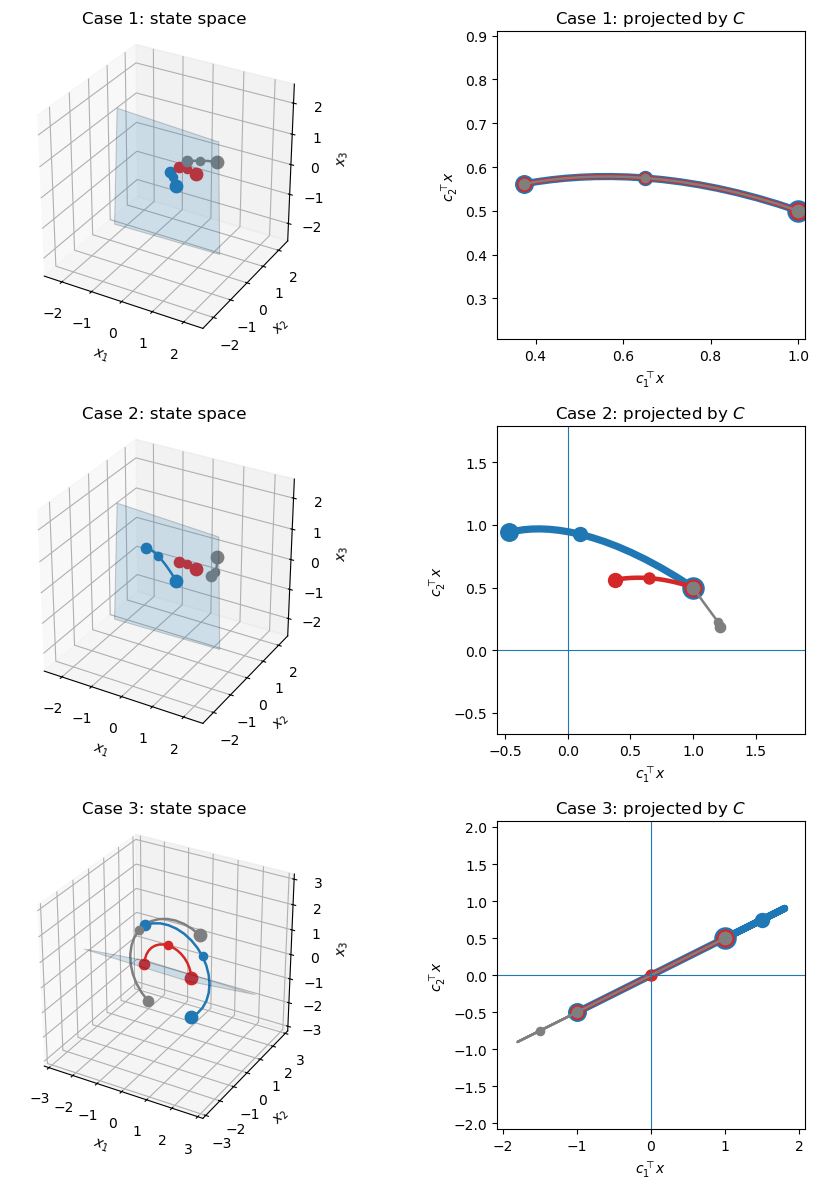

In [32]:
# Don't edit this block

import numpy as np


def rotation_matrix_3d(ax=0.6, ay=0.4, az=0.8):
    """3D rotation matrix: R = Rz Ry Rx."""
    cx, sx = np.cos(ax), np.sin(ax)
    cy, sy = np.cos(ay), np.sin(ay)
    cz, sz = np.cos(az), np.sin(az)

    Rx = np.array([
        [1, 0, 0],
        [0, cx, -sx],
        [0, sx,  cx],
    ])

    Ry = np.array([
        [ cy, 0, sy],
        [  0, 1,  0],
        [-sy, 0, cy],
    ])

    Rz = np.array([
        [cz, -sz, 0],
        [sz,  cz, 0],
        [0,    0, 1],
    ])

    return Rz @ Ry @ Rx


def rotate_case(C, A, x0_list, R):
    """
    Rotate coordinates consistently.

    Original projection convention:
        y = x @ C

    Rotated variables:
        x_rot = R @ x

    Then:
        A_rot = R @ A @ R.T
        C_rot = R @ C
        x0_rot = R @ x0
    """
    C_rot = R @ C
    A_rot = R @ A @ R.T
    x0_rot_list = [R @ x0 for x0 in x0_list]
    return C_rot, A_rot, x0_rot_list

# Base 2D observation plane: observes x and y, not z.
C_xy = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [0.0, 0.0],
])

# Rank-1 observation: observes only x, not y or z.
# This is still stored as 3x2 for plotting.
# The second output coordinate is always zero.
C_rank1 = np.array([
    [1.0, 0.5],
    [0.0, 0.0],
    [0.0, 0.0],
])

x0s_hidden = [
    np.array([1.0, 0.5, -1.0]),
    np.array([1.0, 0.5,  0.0]),
    np.array([1.0, 0.5,  1.0]),
]

# Case 1: hidden difference remains hidden forever.
A_hidden_forever = np.array([
    [0.75, -0.20, 0.00],
    [0.20,  0.75, 0.00],
    [0.00,  0.00, 0.65],
])

# Case 2a: rank-2 C, hidden z becomes visible through A.
A_hidden_then_visible = np.array([
    [0.75, -0.20,  0.55],
    [0.20,  0.75, -0.35],
    [0.00,  0.00,  0.65],
])

# Case 2b: rank-1 C, initially invisible y/z become visible through A.
A_rank1_x0_x2_same = np.array([
    [0.0, -1.0, 0.0],
    [1.0,  0.0, 0.0],
    [0.0,  0.0, 0.7],
])

x0s_rank1 = [
    np.array([1.0, -1.5,  0.0]),
    np.array([1.0,  0.0,  0.0]),
    np.array([1.0,  1.5,  0.5]),
]

R = rotation_matrix_3d(ax=0.7, ay=0.5, az=0.9)

cases = [
    rotate_case(C_xy, A_hidden_forever, x0s_hidden, R),
    rotate_case(C_xy, A_hidden_then_visible, x0s_hidden, R),
    rotate_case(C_rank1, A_rank1_x0_x2_same, x0s_rank1, R),
]

fig = plot_observability_comparison(cases)
plt.show()

## Aliasing intuition from Case 3

Case 3 also gives a simple way to understand **aliasing**.

In that example, the projected observations satisfy:

$$
y_0 = y_2,
$$

but

$$
y_1
$$

is different.

So if we sample the system at every time step, we see the informative intermediate output $y_1$.

However, if we only sample every two time steps, then we observe

$$
y_0, y_2, y_4, \dots
$$

and the important difference at $y_1$ is missed.

This is the basic idea of aliasing:

> sampling too slowly can make different dynamic behaviours appear identical.

In observability terms, the original sampled system may be observable, while a more coarsely sampled version may lose observability because the measurements skip the time points where the hidden state becomes visible.

<h1 style="color: rgb(0, 128, 0);"> Controllability: intuition and structure </h1>

A common misunderstanding about **controllability** is to think that we apply a fixed input (such as an impulse or a step), observe what happens, and conclude that the system cannot reach certain states.

This is not the correct question.

For the system

$$
x_{k+1} = A x_k + B u_k,
$$

we are allowed to **design the entire input sequence**:

$$
u_0, u_1, \dots, u_{n-1}.
$$

The correct question is:

> Given any initial state $x_0$ and any target state $x^*$, does there exist an input sequence such that $x_n = x^*$?

---

## Expansion of the state

By unrolling the dynamics,

$$
x_n = A^n x_0 + \sum_{k=0}^{n-1} A^{n-1-k} B u_k.
$$

So the part we can control is

$$
\sum_{k=0}^{n-1} A^{n-1-k} B u_k.
$$

This is a linear combination of the vectors

$$
B,\ AB,\ A^2B,\ \dots,\ A^{n-1}B.
$$

Therefore, controllability is equivalent to:

> Can these vectors span the entire state space?

---

## Controllability matrix

Define

$$
\mathcal{C} = [\,B\ \ AB\ \ A^2B\,].
$$

In 3D, the system is controllable if and only if

$$
\operatorname{rank}(\mathcal{C}) = 3.
$$

---

## Why more steps do not help

At first glance, one might think:

> Even if $B, AB, A^2B$ do not span $\mathbb{R}^3$, maybe $A^3B$ or later terms will add new directions.

This does not happen.

From the **Cayley--Hamilton theorem** (proved later in the notebook), for a $3\times 3$ matrix $A$ we have

$$
A^3 = c_2 A^2 + c_1 A + c_0 I.
$$

Multiplying by $B$ gives

$$
A^3 B = c_2 A^2 B + c_1 A B + c_0 B.
$$

So $A^3B$ is already a linear combination of

$$
B,\ AB,\ A^2B.
$$

All later vectors behave the same way. Therefore,

$$
\operatorname{span}\{B, AB, A^2B, A^3B, \dots\}
=
\operatorname{span}\{B, AB, A^2B\}.
$$

---

## Key conclusion

> If the system cannot be controlled within $n$ steps (in $n$-dimensional space), then it cannot be controlled at all.

This is fundamentally different from observation:
- Observability collects information over time
- Controllability builds states from a fixed set of directions

---

## Geometric interpretation

- $B$ gives the initial direction we can push the system
- $AB$ shows how dynamics transform that direction
- $A^2B$ shows further transformation

If these directions:
- span $\mathbb{R}^3$ → fully controllable  
- lie in a plane → only partially controllable  
- lie on a line → severely restricted  

---

## Example cases

The following figures illustrate three typical situations.

---

### Case 1: sparse input, but controllable

$B$ has only one non-zero entry, so the input directly affects only one coordinate.

However, $A$ spreads this influence across all coordinates:

$$
B,\ AB,\ A^2B
$$

form three independent directions.

**Conclusion:**  
Even with a very sparse $B$, the system is controllable if the dynamics distribute the input across the space.

---

### Case 2: dense input, but uncontrollable

Here $B$ has three non-zero entries, but

$$
AB = \lambda B,\quad A^2B = \lambda^2 B.
$$

So all controllability vectors lie on the same line:

$$
\operatorname{span}\{B, AB, A^2B\} = \operatorname{span}\{B\}.
$$

**Conclusion:**  
Having many non-zero entries in $B$ does not guarantee controllability.  
If all directions collapse into a single invariant direction, the system is uncontrollable.

---

### Case 3: partial controllability

In this case,

$$
B,\ AB,\ A^2B
$$

span a plane but not the full space.

So:
- some directions are reachable
- some directions are never reachable

**Conclusion:**  
Controllability is not about individual coordinates, but about **subspaces**.

---

## Final takeaway

> Controllability is about whether repeated action of $A$ on $B$ can generate a full basis of the state space.  
> If not, no choice of input sequence and no additional time steps will fix it.

In [34]:
import numpy as np
import matplotlib.pyplot as plt


def plot_controllability_vectors(cases):
    """
    Each case: (C, A, x0_list, B)

    Only A and B are used here.
    Left: text showing A and B
    Right: 3D plot of B, AB, A^2B (unnormalized)

    cases: list of tuples
    """

    n_rows = len(cases)
    fig = plt.figure(figsize=(10, 4 * n_rows))

    for i, case in enumerate(cases):
        # unpack (keep compatibility with previous structure)
        if len(case) == 4:
            C, A, x0_list, B = case
        else:
            raise ValueError("Each case must be (C, A, x0_list, B)")

        A = np.asarray(A, dtype=float)
        B = np.asarray(B, dtype=float).reshape(3)

        # compute vectors
        v0 = B
        v1 = A @ B
        v2 = A @ v1

        vectors = [v0, v1, v2]
        labels = ["$B$", "$AB$", "$A^2B$"]

        # ---- Left: matrix display ----
        ax_text = fig.add_subplot(n_rows, 2, 2 * i + 1)
        ax_text.axis("off")

        text = "A =\n" + np.array2string(A, precision=2, suppress_small=True)
        text += "\n\nB =\n" + np.array2string(B.reshape(-1, 1), precision=2, suppress_small=True)

        ax_text.text(
            0.0, 0.5, text,
            fontsize=10,
            va="center",
            family="monospace"
        )

        # ---- Right: 3D vectors ----
        ax = fig.add_subplot(n_rows, 2, 2 * i + 2, projection="3d")

        colors = ["tab:blue", "tab:orange", "tab:green"]

        for v, label, color in zip(vectors, labels, colors):
            ax.quiver(
                0, 0, 0,
                v[0], v[1], v[2],
                color=color,
                linewidth=2,
                arrow_length_ratio=0.1
            )
            ax.text(v[0], v[1], v[2], label, color=color)

        # set equal limits
        all_pts = np.vstack([np.zeros((1, 3)), np.vstack(vectors)])
        center = all_pts.mean(axis=0)
        radius = np.max(np.linalg.norm(all_pts - center, axis=1))
        radius = max(radius, 1e-6)

        ax.set_xlim(center[0] - radius, center[0] + radius)
        ax.set_ylim(center[1] - radius, center[1] + radius)
        ax.set_zlim(center[2] - radius, center[2] + radius)

        try:
            ax.set_box_aspect([1, 1, 1])
        except Exception:
            pass

        ax.set_title(f"Case {i+1}: $B, AB, A^2B$")
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
        ax.set_zlabel("$x_3$")

    plt.tight_layout()
    return fig

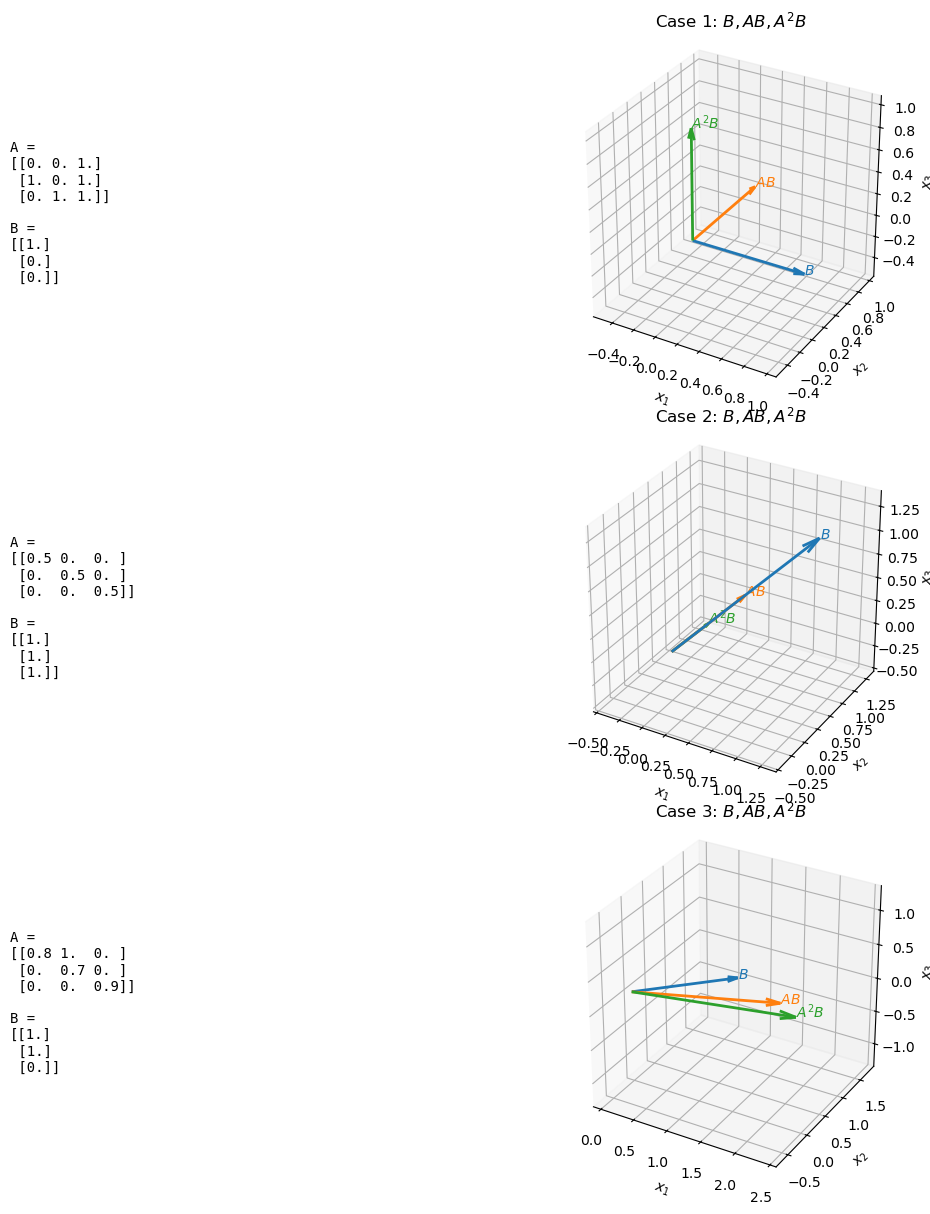

In [36]:
import numpy as np

# Case 1:
# Sparse B, but A spreads the input direction to all 3 dimensions.
A_sparse_B_controllable = np.array([
    [0.0, 0.0, 1.0],
    [1.0, 0.0, 1.0],
    [0.0, 1.0, 1.0],
])

B_sparse = np.array([
    [1.0],
    [0.0],
    [0.0],
])

# Controllability vectors:
# B      = [1, 0, 0]^T
# AB     = [0, 1, 0]^T
# A^2B   = [0, 0, 1]^T


# Case 2:
# Dense B, but B is an eigenvector of A.
# Therefore AB and A^2B stay on the same line.
A_dense_B_uncontrollable = np.diag([0.5, 0.5, 0.5])

B_dense_eigenvector = np.array([
    [1.0],
    [1.0],
    [1.0],
])

# Controllability vectors:
# B      = [1, 1, 1]^T
# AB     = 0.5 [1, 1, 1]^T
# A^2B   = 0.25 [1, 1, 1]^T


# Case 3:
# Partial controllability.
# Input reaches a 2D subspace but never reaches x3.
A_partial = np.array([
    [0.8, 1.0, 0.0],
    [0.0, 0.7, 0.0],
    [0.0, 0.0, 0.9],
])

B_partial = np.array([
    [1.0],
    [1.0],
    [0.0],
])

# Controllability vectors:
# B, AB, A^2B all stay in the x1-x2 plane.
# So the reachable subspace is 2D, not 3D.


controllability_cases = [
    (None, A_sparse_B_controllable, None, B_sparse),
    (None, A_dense_B_uncontrollable, None, B_dense_eigenvector),
    (None, A_partial, None, B_partial),
]

fig = plot_controllability_vectors(controllability_cases)
plt.show()

<h2 style="color: rgb(179, 184, 179);">Cayley-Hamilton Theorem</h2>

Let $A\in M_n(F)$, and define the characteristic polynomial

$$
p_A(t)=\det(tI-A)
=t^n+c_{n-1}t^{n-1}+\cdots+c_1t+c_0.
$$

We prove that

$$
p_A(A)=0.
$$

<h3>1. The adjugate identity</h3>

For any square matrix $M$,

$$
M\operatorname{adj}(M)=\det(M)I.
$$

Indeed, the $(i,j)$-entry of $M\operatorname{adj}(M)$ is

$$
\sum_{k=1}^n m_{ik}C_{jk},
$$

where $C_{jk}$ is the $(j,k)$-cofactor of $M$.

If $i=j$, this is exactly the Laplace expansion of $\det(M)$ along row $i$. If $i\neq j$, it is the determinant of the matrix obtained from $M$ by replacing row $j$ with row $i$, expanded along row $j$. That matrix has two equal rows, so its determinant is $0$.

Hence

$$
(M\operatorname{adj}(M))_{ij}
=
\begin{cases}
\det(M), & i=j,\\
0, & i\neq j.
\end{cases}
$$

Therefore

$$
M\operatorname{adj}(M)=\det(M)I.
$$

Apply this to $M=tI-A$:

$$
(tI-A)\operatorname{adj}(tI-A)=p_A(t)I.
$$

<h3>2. Polynomial degree of the adjugate</h3>

Every entry of $tI-A$ is a polynomial in $t$:

$$
(tI-A)_{ij}
=
\begin{cases}
t-a_{ii}, & i=j,\\
-a_{ij}, & i\neq j.
\end{cases}
$$

So every entry has degree at most $1$.

Each entry of $\operatorname{adj}(tI-A)$ is, up to sign, the determinant of an $(n-1)\times(n-1)$ minor of $tI-A$. By the determinant formula, such a determinant is a sum of products of $n-1$ entries. Each product is a polynomial in $t$ of degree at most $n-1$. Therefore each adjugate entry is a polynomial in $t$ of degree at most $n-1$.

Thus we may write

$$
\operatorname{adj}(tI-A)
=
B_0t^{n-1}+B_1t^{n-2}+\cdots+B_{n-2}t+B_{n-1},
$$

where each $B_k\in M_n(F)$ is a constant matrix.

<h3>3. Comparing polynomial coefficients</h3>

Substitute this into the adjugate identity:

$$
(tI-A)
\left(
B_0t^{n-1}+B_1t^{n-2}+\cdots+B_{n-1}
\right)
=
p_A(t)I.
$$

Both sides are matrix polynomials in $t$. Equivalently, each entry is a scalar polynomial in $t$. Since this identity holds for all scalar choices of $t$, the entries of the difference vanish for infinitely many $t$. By the fundamental theorem of algebra, a nonzero polynomial of degree $d$ has at most $d$ roots. Hence the two matrix polynomials have the same coefficients.

Expanding the left-hand side gives

$$
B_0t^n
+
(B_1-AB_0)t^{n-1}
+
\cdots
+
(B_{n-1}-AB_{n-2})t
-
AB_{n-1}.
$$

Comparing with

$$
p_A(t)I
=
t^nI+c_{n-1}t^{n-1}I+\cdots+c_1tI+c_0I,
$$

we obtain

$$
B_0=I,
$$

and for $1\leq k\leq n-1$,

$$
B_k-AB_{k-1}=c_{n-k}I,
$$

with the final equation

$$
-AB_{n-1}=c_0I.
$$

By induction,

$$
B_k
=
A^k+c_{n-1}A^{k-1}+c_{n-2}A^{k-2}
+\cdots+c_{n-k}I
$$

for $0\leq k\leq n-1$. Equivalently,

$$
B_k=\sum_{r=0}^k c_{n-k+r}A^r,
$$

where $c_n=1$.

Taking $k=n-1$,

$$
B_{n-1}
=
A^{n-1}+c_{n-1}A^{n-2}+\cdots+c_1I.
$$

Using

$$
-AB_{n-1}=c_0I,
$$

we get

$$
-A^n-c_{n-1}A^{n-1}-\cdots-c_1A=c_0I.
$$

Therefore

$$
A^n+c_{n-1}A^{n-1}+\cdots+c_1A+c_0I=0.
$$

Hence

$$
\boxed{p_A(A)=0.}
$$

<h1 style="color: rgb(0, 128, 0);"> From controllability to practical reachability </h1>

Previously, controllability was treated as a yes/no question.

For a 3D discrete-time system,

$$
x_{k+1} = A x_k + B u_k,
$$

the input contribution after $T$ steps is

$$
x_T - A^T x_0
=
\sum_{k=0}^{T-1} A^{T-1-k} B u_k.
$$

Stack the input sequence as

$$
\mathbf{u}
=
\begin{bmatrix}
u_0 \\
u_1 \\
\vdots \\
u_{T-1}
\end{bmatrix}.
$$

Then define the reachability matrix

$$
M_T
=
\begin{bmatrix}
A^{T-1}B & A^{T-2}B & \cdots & B
\end{bmatrix}.
$$

So the state displacement is

$$
x_T - A^T x_0 = M_T \mathbf{u}.
$$

Classical controllability asks whether the columns of $M_T$ can span the whole state space.

Practical controllability asks a different question:

> among the input sequences that are actually allowed, which state displacements can we reach?

---

### Amplitude-bounded input

In practice, the input cannot be arbitrarily large. A simple constraint is

$$
-u_{\max} \le u_k \le u_{\max}.
$$

In stacked form,

$$
-u_{\max}\mathbf{1}
\le
\mathbf{u}
\le
u_{\max}\mathbf{1}.
$$

This is a set of linear inequality constraints on $\mathbf{u}$.

---

### Frequency-bounded input

Sometimes the input is also constrained by frequency content. Since the discrete Fourier transform is a linear map, we can write

$$
\hat{\mathbf{u}} = F\mathbf{u},
$$

where $F$ is the DFT matrix.

If we apply a time-domain window first, with diagonal window matrix $W$, then

$$
\hat{\mathbf{u}}_{\mathrm{win}} = F W \mathbf{u}.
$$

Windowing and DFT are both linear operations.

However, a direct magnitude constraint such as

$$
|\hat u_j| \le \eta_j
$$

is not a linear constraint, because

$$
|\hat u_j|
=
\sqrt{\operatorname{Re}(\hat u_j)^2 + \operatorname{Im}(\hat u_j)^2}.
$$

A common technique is to bound the real and imaginary parts separately:

$$
-\eta_j
\le
\operatorname{Re}(\hat u_j)
\le
\eta_j,
$$

$$
-\eta_j
\le
\operatorname{Im}(\hat u_j)
\le
\eta_j.
$$

Because both

$$
\operatorname{Re}(F W \mathbf{u})
$$

and

$$
\operatorname{Im}(F W \mathbf{u})
$$

are linear functions of $\mathbf{u}$, these become linear inequalities.

So the frequency constraints can be collected as

$$
H_f \mathbf{u} \le h_f.
$$

---

### Practical control as a linear programming problem

Now suppose we want to find the largest reachable displacement in some state-space direction $c$.

The optimization problem is

$$
\max_{\mathbf{u}}
\quad
c^\top M_T \mathbf{u}
$$

subject to

$$
-u_{\max}\mathbf{1}
\le
\mathbf{u}
\le
u_{\max}\mathbf{1},
$$

and

$$
H_f \mathbf{u} \le h_f.
$$

This is a linear programming problem:

- the objective is linear in $\mathbf{u}$
- the amplitude constraints are linear
- the frequency constraints are made linear by bounding real and imaginary parts separately

Therefore, practical controllability can be studied as a constrained reachable-set problem:

$$
\mathcal{R}_T
=
\left\{
M_T\mathbf{u}
\ \middle|\
-u_{\max}\mathbf{1}
\le
\mathbf{u}
\le
u_{\max}\mathbf{1},
\quad
H_f\mathbf{u} \le h_f
\right\}.
$$

Classical controllability tells us whether the full state space is reachable with unrestricted inputs.  
This linear programming formulation tells us which directions are reachable under realistic input constraints.

In [37]:
import numpy as np
import matplotlib.pyplot as plt


def plot_bounded_reachable_points(
    A,
    B,
    *,
    num_u=15,
    u_min=-1.0,
    u_max=1.0,
    figsize=(6, 6),
    point_size=8,
    alpha=0.45,
):
    """
    Plot bounded-input reachable points after 3 steps for a 1D-input,
    3D-state system:

        x_{k+1} = A x_k + B u_k

    assuming x0 = 0 and

        u0, u1, u2 in [u_min, u_max].

    The plotted points are:

        x3 = A^2 B u0 + A B u1 + B u2

    Parameters
    ----------
    A : array, shape (3, 3)
        State transition matrix.

    B : array, shape (3,) or (3, 1)
        Input vector.

    num_u : int
        Number of grid points for each input variable.
        Total plotted points = num_u^3.

    u_min, u_max : float
        Input range.

    Returns
    -------
    fig, ax, points
        points has shape (num_u^3, 3).
    """

    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float).reshape(3, 1)

    if A.shape != (3, 3):
        raise ValueError(f"A must have shape (3, 3), got {A.shape}")
    if B.shape != (3, 1):
        raise ValueError(f"B must have shape (3, 1), got {B.shape}")

    # Controllability directions for 3-step reachability
    v0 = A @ A @ B   # contribution of u0
    v1 = A @ B       # contribution of u1
    v2 = B           # contribution of u2

    us = np.linspace(u_min, u_max, num_u)

    points = []
    for u0 in us:
        for u1 in us:
            for u2 in us:
                x = v0 * u0 + v1 * u1 + v2 * u2
                points.append(x.reshape(3))

    points = np.vstack(points)

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(
        points[:, 0],
        points[:, 1],
        points[:, 2],
        s=point_size,
        alpha=alpha,
    )

    # Also show the three generating directions
    generators = [v0.reshape(3), v1.reshape(3), v2.reshape(3)]
    labels = [r"$A^2B$", r"$AB$", r"$B$"]

    for v, label in zip(generators, labels):
        ax.quiver(
            0, 0, 0,
            v[0], v[1], v[2],
            linewidth=2,
            arrow_length_ratio=0.08,
        )
        ax.text(v[0], v[1], v[2], label)

    # Tight equal limits
    all_pts = np.vstack([points, np.zeros((1, 3)), np.vstack(generators)])
    mn = all_pts.min(axis=0)
    mx = all_pts.max(axis=0)
    ctr = (mn + mx) / 2
    radius = max((mx - mn).max() / 2, 1e-6) * 1.05

    ax.set_xlim(ctr[0] - radius, ctr[0] + radius)
    ax.set_ylim(ctr[1] - radius, ctr[1] + radius)
    ax.set_zlim(ctr[2] - radius, ctr[2] + radius)

    try:
        ax.set_box_aspect([1, 1, 1])
    except Exception:
        pass

    ax.set_title(r"Bounded-input reachable points: $u_0,u_1,u_2 \in [-1,1]$")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_zlabel(r"$x_3$")

    plt.tight_layout()
    return fig, ax, points

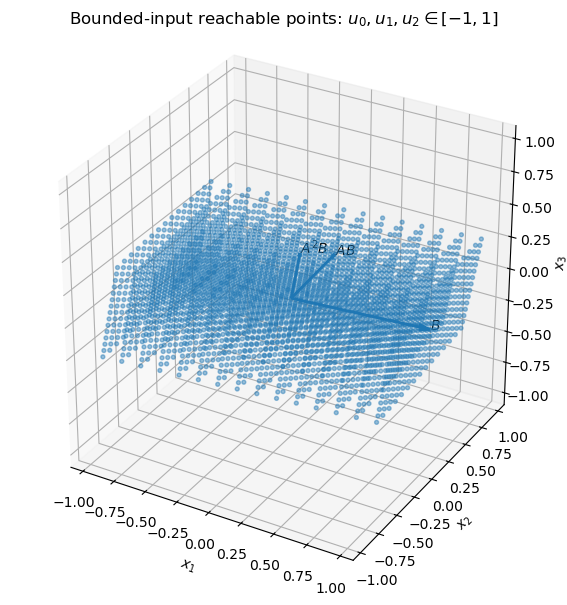

In [43]:
A_sparse_B_controllable = np.array([
    [0.0, 0.0, 0.9],
    [0.6, 0.0, 0.8],
    [0.0, 0.5, 0.8],
])

B_sparse = np.array([
    [1.0],
    [0.1],
    [0.0],
])

fig, ax, points = plot_bounded_reachable_points(
    A_sparse_B_controllable,
    B_sparse,
    num_u=15,
    u_min=-1,
    u_max=1,
)

plt.show()